# Deliverable 3: Classification, Clustering, and Pattern Mining

## Advanced Data Mining Project

Dataset: `ecommerce_user_dataset_cleaned.csv`

This notebook covers all Deliverable 3 requirements:

- Build and evaluate at least two classification models
- Perform hyperparameter tuning for one classifier
- Evaluate with confusion matrix, ROC curve, accuracy, and F1 score
- Build and interpret a clustering model
- Apply association rule mining and interpret practical patterns


In [ ]:
# Core imports and notebook display settings
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

# Optional visualization helper
try:
    import seaborn as sns
    sns.set_theme(style='whitegrid')
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

# Scikit-learn imports for preprocessing, modeling, and evaluation

print('Seaborn available:', HAS_SEABORN)

Seaborn available: True


In [2]:
# Load dataset
df = pd.read_csv('ecommerce_user_dataset_cleaned.csv')

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
display(df.head())
display(df.describe(include='all').T)

Shape: (1000, 8)
Columns: ['Customer_ID', 'Purchase_History', 'Transaction_Frequency', 'Monetary_Value', 'Browsing_Behavior', 'Engagement_Score', 'Time_on_Site', 'Customer_Segment']


,Customer_ID,Purchase_History,Transaction_Frequency,Monetary_Value,Browsing_Behavior,Engagement_Score,Time_on_Site,Customer_Segment
0,CUST0001,23,0.2577,664.0900,88.1000,0.2600,11.8400,Iron
1,CUST0002,15,0.3785,"4,244.2100",5.8700,0.2800,35.0400,Copp
2,CUST0003,21,2.5781,"4,638.4700",23.8800,0.9300,10.1400,Copp
3,CUST0004,25,1.7498,"7,277.5600",89.8400,0.0200,22.0200,Iron
4,CUST0005,15,1.3223,"5,785.4500",26.3600,0.7000,42.1200,Copp


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer_ID,1000,1000,CUST0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Purchase_History,"1,000.0000",NaN,NaN,NaN,19.8790,4.5615,8.0000,17.0000,20.0000,23.0000,32.0000
Transaction_Frequency,"1,000.0000",NaN,NaN,NaN,4.6869,4.1306,0.0001,1.4262,3.4695,6.8135,14.8943
Monetary_Value,"1,000.0000",NaN,NaN,NaN,"4,926.2117","2,819.0933",100.3000,"2,455.9975","4,890.7250","7,311.5775","9,995.6200"
Browsing_Behavior,"1,000.0000",NaN,NaN,NaN,50.2197,28.4882,1.0200,25.9775,48.7500,75.3825,99.8800
Engagement_Score,"1,000.0000",NaN,NaN,NaN,0.4997,0.2927,0.0000,0.2400,0.5000,0.7600,1.0000
Time_on_Site,"1,000.0000",NaN,NaN,NaN,29.8492,16.7392,1.0100,15.4925,29.3800,44.1450,59.9500
Customer_Segment,1000,2,Copp,718,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1) Classification Setup

We classify `Customer_Segment` using numeric behavior features plus engineered features.

Models used:

- Decision Tree Classifier
- k-Nearest Neighbors (k-NN) Classifier

Hyperparameter tuning is applied to k-NN using `GridSearchCV`.


In [ ]:
# Feature engineering for classification and clustering stages
df_model = df.copy()

# Interaction and normalized ratio features often improve boundary separation
df_model['purchase_freq_interaction'] = df_model['Purchase_History'] * \
    df_model['Transaction_Frequency']
df_model['engagement_time_interaction'] = df_model['Engagement_Score'] * \
    df_model['Time_on_Site']
df_model['browsing_per_visit'] = df_model['Browsing_Behavior'] / \
    (df_model['Transaction_Frequency'] + 1)
df_model['purchase_per_visit'] = df_model['Purchase_History'] / \
    (df_model['Transaction_Frequency'] + 1)

# Binary encoding for ROC curve compatibility
segment_order = sorted(df_model['Customer_Segment'].dropna().unique().tolist())
segment_map = {segment_order[0]: 0, segment_order[1]: 1}
df_model['Target_Binary'] = df_model['Customer_Segment'].map(segment_map)

feature_cols = [
    'Purchase_History',
    'Transaction_Frequency',
    'Monetary_Value',
    'Browsing_Behavior',
    'Engagement_Score',
    'Time_on_Site',
    'purchase_freq_interaction',
    'engagement_time_interaction',
    'browsing_per_visit',
    'purchase_per_visit'
]

X = df_model[feature_cols]
y = df_model['Target_Binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Segment mapping used for binary target:', segment_map)
print('Train shape:', X_train.shape, y_train.shape)
print('Test shape:', X_test.shape, y_test.shape)

Segment mapping used for binary target: {'Copp': 0, 'Iron': 1}
Train shape: (800, 10) (800,)
Test shape: (200, 10) (200,)


In [4]:
# Common preprocessing pipeline (median imputation + scaling for numeric features)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[('num', numeric_transformer, feature_cols)]
)

# Model 1: Decision Tree (baseline)
tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42, max_depth=5))
])

# Model 2: k-NN (to be tuned)
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier())
])

In [5]:
# Hyperparameter tuning for k-NN using GridSearchCV
param_grid = {
    'model__n_neighbors': [3, 5, 7, 9, 11],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)
best_knn = grid_search.best_estimator_

print('Best k-NN parameters:', grid_search.best_params_)
print(f"Best CV F1 score: {grid_search.best_score_:.4f}")

Best k-NN parameters: {'model__metric': 'manhattan', 'model__n_neighbors': 5, 'model__weights': 'distance'}
Best CV F1 score: 0.7119


In [ ]:
# Fit decision tree and tuned k-NN, then evaluate both models
tree_pipeline.fit(X_train, y_train)

models = {
    'DecisionTree': tree_pipeline,
    'TunedKNN': best_knn
}

classification_results = []
pred_store = {}
proba_store = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    pred_store[name] = y_pred
    proba_store[name] = y_proba

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    classification_results.append({
        'Model': name,
        'Accuracy': accuracy,
        'F1_Score': f1
    })

results_clf_df = pd.DataFrame(classification_results).sort_values(
    by='F1_Score', ascending=False)
display(results_clf_df)

,Model,Accuracy,F1_Score
0,DecisionTree,1.0000,1.0000
1,TunedKNN,0.8800,0.7692


In [7]:
# Confusion matrices and classification reports
for name in models:
    print('=' * 70)
    print(f'Model: {name}')

    cm = confusion_matrix(y_test, pred_store[name])
    print('Confusion Matrix:')
    print(cm)

    print('Classification Report:')
    print(classification_report(y_test, pred_store[name], digits=4))

Model: DecisionTree
Confusion Matrix:
[[144   0]
 [  0  56]]
Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       144
           1     1.0000    1.0000    1.0000        56

    accuracy                         1.0000       200
   macro avg     1.0000    1.0000    1.0000       200
weighted avg     1.0000    1.0000    1.0000       200

Model: TunedKNN
Confusion Matrix:
[[136   8]
 [ 16  40]]
Classification Report:
              precision    recall  f1-score   support

           0     0.8947    0.9444    0.9189       144
           1     0.8333    0.7143    0.7692        56

    accuracy                         0.8800       200
   macro avg     0.8640    0.8294    0.8441       200
weighted avg     0.8775    0.8800    0.8770       200



<Figure size 800x600 with 0 Axes>

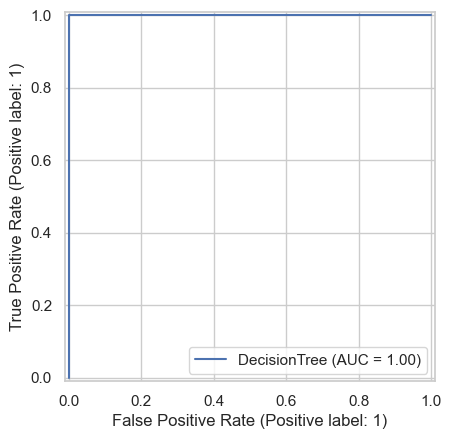

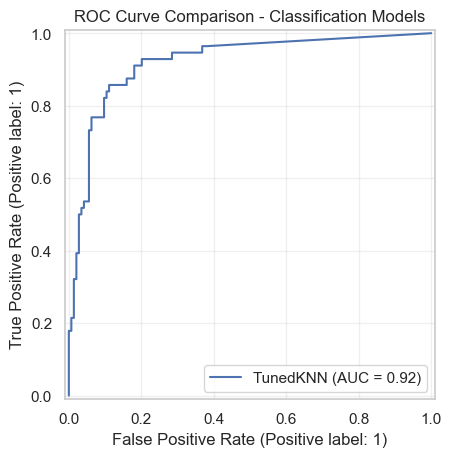

In [8]:
# ROC curve comparison
plt.figure(figsize=(8, 6))

for name in models:
    RocCurveDisplay.from_predictions(
        y_test,
        proba_store[name],
        name=name
    )

plt.title('ROC Curve Comparison - Classification Models')
plt.grid(alpha=0.3)
plt.show()

## 2) Clustering

We apply **K-Means** clustering to discover latent customer groups from behavioral features.

For visualization, we project features to 2D using PCA and color points by cluster label.


In [9]:
# Prepare data for clustering
cluster_features = feature_cols

cluster_preprocess = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_cluster = cluster_preprocess.fit_transform(df_model[cluster_features])

# K-Means with 3 clusters (interpretable segmentation level)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_cluster)

df_model['Cluster'] = cluster_labels

print('Cluster counts:')
print(df_model['Cluster'].value_counts().sort_index())

Cluster counts:
Cluster
0    304
1    330
2    366
Name: count, dtype: int64


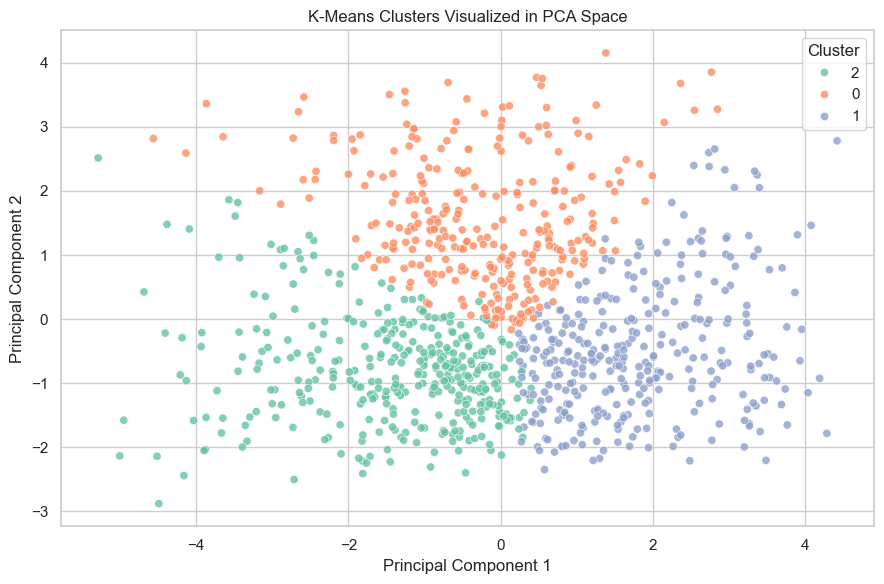

In [ ]:
# 2D visualization of clustering via PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': df_model['Cluster'].astype(str)
})

plt.figure(figsize=(9, 6))
if HAS_SEABORN:
    sns.scatterplot(data=plot_df, x='PC1', y='PC2',
                    hue='Cluster', palette='Set2', alpha=0.8)
else:
    for c in sorted(plot_df['Cluster'].unique()):
        subset = plot_df[plot_df['Cluster'] == c]
        plt.scatter(subset['PC1'], subset['PC2'],
                    label=f'Cluster {c}', alpha=0.8)
    plt.legend()

plt.title('K-Means Clusters Visualized in PCA Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()

In [ ]:
# Explain clusters with profile averages
cluster_profile = df_model.groupby(
    'Cluster')[cluster_features + ['Target_Binary']].mean().round(3)
display(cluster_profile)

print('Cluster interpretation tip: compare high/low averages to describe each group.')

,Purchase_History,Transaction_Frequency,Monetary_Value,Browsing_Behavior,Engagement_Score,Time_on_Site,purchase_freq_interaction,engagement_time_interaction,browsing_per_visit,purchase_per_visit,Target_Binary
Cluster,,,,,,,,,,,
0,18.9840,3.6780,"4,926.9450",47.8910,0.7400,40.9760,70.5400,29.4960,13.1800,5.3640,0.1450
1,20.5150,9.1180,"4,853.3300",48.1680,0.4100,24.8130,186.2850,9.0330,5.2820,2.3120,0.3520
2,20.0490,1.5300,"4,991.3160",54.0030,0.3810,25.1470,30.5790,8.0540,25.8720,9.7980,0.3330


Cluster interpretation tip: compare high/low averages to describe each group.


## 3) Association Rule Mining (Apriori)

We discretize numeric behavioral variables into bins and mine frequent itemsets/rules.

Rules with stronger confidence and lift can guide practical actions such as targeting campaigns and bundles.


In [12]:
# Ensure mlxtend is available for Apriori and association rules
try:
    from mlxtend.frequent_patterns import apriori, association_rules
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'mlxtend'])
    from mlxtend.frequent_patterns import apriori, association_rules

print('mlxtend is available.')

  Using cached mlxtend-0.24.0-py3-none-any.whl.metadata (7.3 kB)
Using cached mlxtend-0.24.0-py3-none-any.whl (1.4 MB)
mlxtend is available.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
# Build transaction-like basket data using binned behavioral features
assoc_df = df_model.copy()

bin_cols = ['Purchase_History', 'Transaction_Frequency',
            'Monetary_Value', 'Engagement_Score', 'Time_on_Site']
for col in bin_cols:
    assoc_df[f'{col}_bin'] = pd.qcut(
        assoc_df[col], q=3, labels=['low', 'mid', 'high'])

# Construct categorical tokens for each row to mimic basket items
token_cols = [f'{c}_bin' for c in bin_cols] + ['Customer_Segment']
for col in token_cols:
    assoc_df[col] = col + '=' + assoc_df[col].astype(str)

transactions = assoc_df[token_cols]

# One-hot encode tokens for Apriori
one_hot = pd.get_dummies(transactions)

# Mine frequent itemsets
frequent_itemsets = apriori(one_hot, min_support=0.08, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)

print('Top frequent itemsets:')
display(frequent_itemsets.head(10))

Top frequent itemsets:


,support,itemsets
15,0.7180,frozenset({Customer_Segment_Customer_Segment=C...
1,0.3940,frozenset({Purchase_History_bin_Purchase_Histo...
11,0.3390,frozenset({Engagement_Score_bin_Engagement_Sco...
10,0.3370,frozenset({Engagement_Score_bin_Engagement_Sco...
4,0.3340,frozenset({Transaction_Frequency_bin_Transacti...
7,0.3340,frozenset({Monetary_Value_bin_Monetary_Value_b...
13,0.3340,frozenset({Time_on_Site_bin_Time_on_Site_bin=l...
3,0.3330,frozenset({Transaction_Frequency_bin_Transacti...
5,0.3330,frozenset({Transaction_Frequency_bin_Transacti...
6,0.3330,frozenset({Monetary_Value_bin_Monetary_Value_b...


In [ ]:
# Generate association rules and filter for meaningful ones
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.1)

if len(rules) == 0:
    print('No rules met current threshold; consider lowering min_support or min_threshold.')
else:
    rules = rules[['antecedents', 'consequents',
                   'support', 'confidence', 'lift']].copy()
    rules = rules.sort_values(['lift', 'confidence'], ascending=False)
    display(rules.head(15))

,antecedents,consequents,support,confidence,lift
184,frozenset({Monetary_Value_bin_Monetary_Value_b...,frozenset({Customer_Segment_Customer_Segment=I...,0.0800,0.6838,2.4247
189,frozenset({Customer_Segment_Customer_Segment=I...,frozenset({Monetary_Value_bin_Monetary_Value_b...,0.0800,0.2837,2.4247
8,frozenset({Engagement_Score_bin_Engagement_Sco...,frozenset({Customer_Segment_Customer_Segment=I...,0.1820,0.5401,1.9151
9,frozenset({Customer_Segment_Customer_Segment=I...,frozenset({Engagement_Score_bin_Engagement_Sco...,0.1820,0.6454,1.9151
11,frozenset({Customer_Segment_Customer_Segment=I...,frozenset({Monetary_Value_bin_Monetary_Value_b...,0.1800,0.6383,1.9111
10,frozenset({Monetary_Value_bin_Monetary_Value_b...,frozenset({Customer_Segment_Customer_Segment=I...,0.1800,0.5389,1.9111
18,frozenset({Engagement_Score_bin_Engagement_Sco...,frozenset({Customer_Segment_Customer_Segment=C...,0.1250,1.0000,1.3928
48,frozenset({Engagement_Score_bin_Engagement_Sco...,frozenset({Customer_Segment_Customer_Segment=C...,0.1150,1.0000,1.3928
76,frozenset({Engagement_Score_bin_Engagement_Sco...,frozenset({Customer_Segment_Customer_Segment=C...,0.1050,1.0000,1.3928
102,frozenset({Engagement_Score_bin_Engagement_Sco...,frozenset({Customer_Segment_Customer_Segment=C...,0.1010,1.0000,1.3928


## 4) Practical Insights and Real-World Application

Use your output tables/plots to report:

1. **Classification insights**

- Which model gave the highest F1 and why it is suitable under class imbalance.
- What confusion matrix errors imply for business decisions (false positives vs false negatives).

2. **Clustering insights**

- Distinct behavioral groups (for example: high-value/high-engagement vs low-frequency users).
- How targeted retention, upsell, or reactivation strategies can be designed per cluster.

3. **Pattern mining insights**

- High-lift rules indicate co-occurring behavior states useful for recommendation logic.
- Marketing can use these rules to trigger personalized messaging and product bundles.
